Passo 1: Bloco de importação de bibliotecas — cole e use-as no topo do seu notebook dataview.ipynb

In [28]:
#Importar as bibliotecas

import pandas as pd
import numpy as np
import random
import os
import json
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta

RF01 – Criar ou Carregar o Dataset de Vendas

O projeto deve usar um dataset de vendas com ao menos as colunas: id | data | cliente | produto | categoria | regiao | quantidade | preco

O dataset deve conter dados intencionalmente sujos: valores None, datas inválidas e espaços extras em strings — para você praticar a limpeza na RF03.

O projeto deverá incluir um dataset de vendas. O estudante pode gerar o dataset sinteticamente no próprio código (recomendado para facilitar a reprodução) ou utilizar um arquivo CSV real. Opção A – Gerar o dataset no código (recomendado):

In [29]:
# Gerar dataset de vendas

def gerar_dataset_vendas(n_registros=1500, seed=42):

    random.seed(seed)
    np.random.seed(seed)

    produtos = ["Notebook","Smartphone","Tablet","Monitor","Teclado","Mouse"]

    precos = {
        "Notebook":3500,
        "Smartphone":2200,
        "Tablet":1800,
        "Monitor":1200,
        "Teclado":250,
        "Mouse":120
    }

    categorias = {
        "Notebook":"Computadores",
        "Smartphone":"Celulares",
        "Tablet":"Celulares",
        "Monitor":"Computadores",
        "Teclado":"Periféricos",
        "Mouse":"Periféricos"
    }

    regioes = ["Sul","Sudeste","Nordeste","Centro-Oeste","Norte"]

    clientes = [f"Cliente_{i:03d}" for i in range(1,31)]

    data_inicio = datetime(2024,1,1)

    dados=[]

    for i in range(n_registros):

        produto = random.choice(produtos)

        dados.append({

            "id":i+1,

            "data":(data_inicio + timedelta(days=random.randint(0,364))).strftime("%Y-%m-%d"),

            "cliente":random.choice(clientes),

            "produto":produto,

            "categoria":categorias[produto],

            "regiao":random.choice(regioes),

            "quantidade":random.randint(1,10),

            "preco":precos[produto]

        })

    df = pd.DataFrame(dados)
    
    return df


In [30]:
# Inserir dados sujos no dataset

df = gerar_dataset_vendas()

# 60 clientes com espaços
idx = np.random.choice(df.index,60,replace=False)
df.loc[idx,"cliente"] = (
" " + df.loc[idx,"cliente"] + " "
)

# 30 regiões com espaços
idx = np.random.choice(df.index,30,replace=False)
df.loc[idx,"regiao"] = (
" " + df.loc[idx,"regiao"]
)

# 5 clientes nulos
idx = np.random.choice(df.index,5,replace=False)
df.loc[idx,"cliente"] = None

# 3 produtos nulos
idx = np.random.choice(df.index,3,replace=False)
df.loc[idx,"produto"] = None

# 10 quantidades nulas
idx = np.random.choice(df.index,10,replace=False)
df.loc[idx,"quantidade"] = None

#Preços nulos
idx = np.random.choice(df.index,5,replace=False)
df.loc[idx,"preco"] = None

#50 datas inválidas
datas_invalidas = [
"31/02/2024",
"99/99/9999",
"abc",
"",
"32/01/2024",
"2024-15-01",
"2024-02-30",
"15-15-2024",
"2024/99/10",
"data_invalida"
]

idx = np.random.choice(df.index,50,replace=False)

for i, linha in enumerate(idx):
    df.loc[linha,"data"] = datas_invalidas[i % len(datas_invalidas)]



# Outliers em preço e quantidade
idx = np.random.choice(df.index, 10, replace=False)
df.loc[idx, "preco"] = np.random.randint(30000, 100000, 10)

idx = np.random.choice(df.index, 20, replace=False)
df.loc[idx, "quantidade"] = np.random.randint(500, 1500, 20)

# Seleciona 50 linhas aleatórias
duplicados = df.sample(n=50, random_state=42)

# Adiciona essas linhas novamente ao DataFrame
df = pd.concat([df, duplicados], ignore_index=True)



print("Dados sujos adicionados com sucesso!")

# Salvar dataset com dados sujos

df.to_csv("../data/raw/vendas_sujo.csv", index=False)

print(df.head())

Dados sujos adicionados com sucesso!
   id        data      cliente     produto     categoria    regiao  \
0   1  2024-02-27  Cliente_001       Mouse   Periféricos  Nordeste   
1   2  2024-03-12  Cliente_024  Smartphone     Celulares       Sul   
2   3  2024-10-29  Cliente_014    Notebook  Computadores       Sul   
3   4  2024-04-21  Cliente_008    Notebook  Computadores     Norte   
4   5  2024-10-14  Cliente_007    Notebook  Computadores     Norte   

   quantidade   preco  
0         4.0   120.0  
1         9.0  2200.0  
2         1.0  3500.0  
3        10.0  3500.0  
4         7.0  3500.0  


In [33]:
#Conferir o dataset sujo


import pandas as pd




# INSPEÇÃO DOS DADOS SUJOS


print("=" * 60)
print("PRIMEIRAS 5 LINHAS")
print("=" * 60)
print(df.head())

print("\n" + "=" * 60)
print("ÚLTIMAS 5 LINHAS")
print("=" * 60)
print(df.tail())

print("\n" + "=" * 60)
print("DIMENSÕES DO DATASET")
print("=" * 60)
print(f"Linhas : {df.shape[0]}")
print(f"Colunas: {df.shape[1]}")

print("\n" + "=" * 60)
print("TIPOS DE DADOS")
print("=" * 60)
print(df.dtypes)

print("\n" + "=" * 60)
print("INFORMAÇÕES GERAIS")
print("=" * 60)
df.info()

print("\n" + "=" * 60)
print("VALORES NULOS")
print("=" * 60)
print(df.isnull().sum())

print("\n" + "=" * 60)
print("REGISTROS DUPLICADOS")
print("=" * 60)
print(df.duplicated().sum())

print("\n" + "=" * 60)
print("ESTATÍSTICAS DESCRITIVAS")
print("=" * 60)
print(df.describe())

print("\n" + "=" * 60)
print("ESTATÍSTICAS (INCLUINDO COLUNAS DE TEXTO)")
print("=" * 60)
print(df.describe(include="all"))

PRIMEIRAS 5 LINHAS
   id        data      cliente     produto     categoria    regiao  \
0   1  2024-02-27  Cliente_001       Mouse   Periféricos  Nordeste   
1   2  2024-03-12  Cliente_024  Smartphone     Celulares       Sul   
2   3  2024-10-29  Cliente_014    Notebook  Computadores       Sul   
3   4  2024-04-21  Cliente_008    Notebook  Computadores     Norte   
4   5  2024-10-14  Cliente_007    Notebook  Computadores     Norte   

   quantidade   preco  
0         4.0   120.0  
1         9.0  2200.0  
2         1.0  3500.0  
3        10.0  3500.0  
4         7.0  3500.0  

ÚLTIMAS 5 LINHAS
       id        data        cliente   produto     categoria   regiao  \
1545  355  2024-05-26   Cliente_003     Tablet     Celulares      Sul   
1546  366  2024-12-02   Cliente_030     Tablet     Celulares    Norte   
1547  310  2024-10-27   Cliente_018   Notebook  Computadores    Norte   
1548  737  2024-03-09   Cliente_021    Monitor  Computadores  Sudeste   
1549  999  2024-11-30   Cliente_0

RF03 – Limpar e Tratar os Dados O projeto deverá realizar a limpeza dos dados. O estudante deve tratar ao menos os seguintes problemas: Remover ou imputar linhas com valores nulos nas colunas críticas (quantidade, preco_unitario); Remover linhas com datas inválidas; Converter a coluna de data para o tipo datetime; Remover espaços extras em colunas de texto com .str.strip(); Registrar no console quantos registros foram removidos.

In [24]:
# Carregar o dataset

df = pd.read_csv("../data/raw/vendas_sujo.csv")

print("=" * 50)
print("INICIANDO LIMPEZA DOS DADOS")
print("=" * 50)

# Quantidade inicial
registros_iniciais = len(df)


# Remover espaços extras


colunas_texto = [
    "cliente",
    "produto",
    "categoria",
    "regiao"
]

for coluna in colunas_texto:
    df[coluna] = df[coluna].astype(str).str.strip()

# Converter data

df["data"] = pd.to_datetime(df["data"], errors="coerce")


# Remover datas inválidas

antes = len(df)

df = df.dropna(subset=["data"])

datas_removidas = antes - len(df)


# Remover valores nulos


antes = len(df)

df = df.dropna(subset=["cliente","quantidade", "preco", "produto"])

nulos_removidos = antes - len(df)


df = df.drop_duplicates().reset_index(drop=True)
duplicados_removidos = registros_iniciais - len(df) - datas_removidas - nulos_removidos


# Total removido

registros_finais = len(df)

total_removidos = registros_iniciais - registros_finais


# Exibir resumo


print("\nResumo da Limpeza")

print("-" * 30)

print(f"Registros iniciais : {registros_iniciais}")
print(f"Datas inválidas removidas : {datas_removidas}")
print(f"Nulos removidos : {nulos_removidos}")
print(f"Duplicados removidos : {duplicados_removidos}")
print(f"Total removido : {total_removidos}")
print(f"Regitros finais : {registros_finais}")


# Salvar dataset limpo


df.to_csv(
    "../data/processed/v1_com_outliers/vendas_limpo.csv",
    index=False
)

print("\nArquivo salvo com sucesso!")
print("../data/processed/v1_com_outliers/vendas_limpo.csv")

INICIANDO LIMPEZA DOS DADOS

Resumo da Limpeza
------------------------------
Registros iniciais : 1550
Datas inválidas removidas : 53
Nulos removidos : 22
Duplicados removidos : 46
Total removido : 121
Regitros finais : 1429

Arquivo salvo com sucesso!
../data/processed/v1_com_outliers/vendas_limpo.csv


In [34]:
#Conferir o dataset limpo


import pandas as pd

# Carregar o dataset
vendasl = pd.read_csv("../data/processed/v1_com_outliers/vendas_limpo.csv")


# INSPEÇÃO DOS DADOS


print("=" * 60)
print("PRIMEIRAS 5 LINHAS")
print("=" * 60)
print(vendasl.head())

print("\n" + "=" * 60)
print("ÚLTIMAS 5 LINHAS")
print("=" * 60)
print(vendasl.tail())

print("\n" + "=" * 60)
print("DIMENSÕES DO DATASET")
print("=" * 60)
print(f"Linhas : {vendasl.shape[0]}")
print(f"Colunas: {vendasl.shape[1]}")

print("\n" + "=" * 60)
print("TIPOS DE DADOS")
print("=" * 60)
print(vendasl.dtypes)

print("\n" + "=" * 60)
print("INFORMAÇÕES GERAIS")
print("=" * 60)
vendasl.info()

print("\n" + "=" * 60)
print("VALORES NULOS")
print("=" * 60)
print(vendasl.isnull().sum())

print("\n" + "=" * 60)
print("REGISTROS DUPLICADOS")
print("=" * 60)
print(vendasl.duplicated().sum())

print("\n" + "=" * 60)
print("ESTATÍSTICAS DESCRITIVAS")
print("=" * 60)
print(vendasl.describe())

print("\n" + "=" * 60)
print("ESTATÍSTICAS (INCLUINDO COLUNAS DE TEXTO)")
print("=" * 60)
print(vendasl.describe(include="all"))

PRIMEIRAS 5 LINHAS
   id        data      cliente     produto     categoria    regiao  \
0   1  2024-02-27  Cliente_001       Mouse   Periféricos  Nordeste   
1   2  2024-03-12  Cliente_024  Smartphone     Celulares       Sul   
2   3  2024-10-29  Cliente_014    Notebook  Computadores       Sul   
3   4  2024-04-21  Cliente_008    Notebook  Computadores     Norte   
4   5  2024-10-14  Cliente_007    Notebook  Computadores     Norte   

   quantidade   preco  
0         4.0   120.0  
1         9.0  2200.0  
2         1.0  3500.0  
3        10.0  3500.0  
4         7.0  3500.0  

ÚLTIMAS 5 LINHAS
        id        data      cliente     produto     categoria        regiao  \
1424  1495  2024-11-01  Cliente_025       Mouse   Periféricos  Centro-Oeste   
1425  1496  2024-11-26  Cliente_022     Monitor  Computadores           Sul   
1426  1498  2024-12-04  Cliente_005  Smartphone     Celulares  Centro-Oeste   
1427  1499  2024-07-18  Cliente_020      Tablet     Celulares         Norte   
142

RF04 – Detectar e Tratar Outliers (versões v1 e v2) Após a limpeza geral (RF03), o estudante deve trabalhar os outliers das colunas numéricas e gerar duas versões dos dados, salvas em data/processed/: v1_com_outliers/ — os dados limpos da RF03, com os outliers mantidos; v2_outliers_tratado/ — a mesma base da v1, agora com os outliers tratados (removidos ou substituídos). Espera-se que o estudante: detecte os outliers com um método estatístico (IQR ou z-score); gere as limpezas de dados v1 e v2; e registre no notebook quantos outliers foram encontrados. O ponto central é a reutilização: a mesma função de limpeza alimenta ambas as versões.

In [35]:
# Salvar o dataset limpo para a versão 1 (v1) com outliers
df_v1 = vendasl.copy()

df_v1.to_csv(
    "../data/processed/v1_com_outliers/vendas_v1.csv",
    index=False
)

In [39]:
#Utilizar a função tratar_outliers para remover outliers do dataset limpo

import pandas as pd

def tratar_outliers(df, colunas, fator=1.5, metodo="remover"):
    """
    Detecta e trata outliers usando o método IQR.

    Parâmetros:
        df: DataFrame
        colunas: lista de colunas numéricas
        fator: multiplicador do IQR (padrão = 1.5)
        metodo:
            'remover' -> remove as linhas
            'limitar' -> substitui pelos limites (winsorização)
    """

    df = df.copy()

    for col in colunas:

        q1 = df[col].quantile(0.25)
        q3 = df[col].quantile(0.75)

        iqr = q3 - q1

        limite_inferior = q1 - fator * iqr
        limite_superior = q3 + fator * iqr

        outliers = (
            (df[col] < limite_inferior) |
            (df[col] > limite_superior)
        )

        print(f"{col}: {outliers.sum()} outliers encontrados")

        if metodo == "remover":
            df = df[~outliers]

        else:
            df[col] = df[col].clip(
                lower=limite_inferior,
                upper=limite_superior
            )

    return df

In [43]:
#Criação das colunas temporárias para calcular a receita total
df_v1_tmp = df_v1.copy()

df_v1_tmp["receita_total"] = (
    df_v1_tmp["quantidade"] *
    df_v1_tmp["preco"]
)

In [47]:
#Visualizar as primeiras linhas do dataset temporário
print(df_v1_tmp.head())

   id        data      cliente     produto     categoria    regiao  \
0   1  2024-02-27  Cliente_001       Mouse   Periféricos  Nordeste   
1   2  2024-03-12  Cliente_024  Smartphone     Celulares       Sul   
2   3  2024-10-29  Cliente_014    Notebook  Computadores       Sul   
3   4  2024-04-21  Cliente_008    Notebook  Computadores     Norte   
4   5  2024-10-14  Cliente_007    Notebook  Computadores     Norte   

   quantidade   preco  receita_total  
0         4.0   120.0          480.0  
1         9.0  2200.0        19800.0  
2         1.0  3500.0         3500.0  
3        10.0  3500.0        35000.0  
4         7.0  3500.0        24500.0  


In [51]:
#Gerar a versao v2, Aplicar a função tratar_outliers para remover outliers das colunas "quantidade" e "receita_total"

df_v2 = tratar_outliers(

    df_v1_tmp,

    colunas=[
        "quantidade",
        "receita_total"
    ],

    metodo="remover"

)

quantidade: 18 outliers encontrados
receita_total: 60 outliers encontrados


In [ ]:
#Remover a coluna temporária "receita_total" do dataset v2
df_v2.drop(
    columns="receita_total",
    inplace=True
)

In [ ]:
#Comparar o número de linhas entre v1 e v2
print()

print(f"v1 = {len(df_v1)} linhas")

print(f"v2 = {len(df_v2)} linhas")

print(f"Foram removidas {len(df_v1)-len(df_v2)} linhas.")


v1 = 1429 linhas
v2 = 1351 linhas
Foram removidas 78 linhas.


In [ ]:
#Geração do diretório para salvar o dataset v2 tratado

os.makedirs(
    "../data/processed/v2_outliers_tratado",
    exist_ok=True
)

df_v2.to_csv(
    "../data/processed/v2_outliers_tratado/vendas_v2.csv",
    index=False
)

print("v2 salva com sucesso.")

v2 salva com sucesso.


A versão v2 foi escolhida porque, além da limpeza de valores nulos, datas inválidas e espaços extras, os outliers das colunas quantidade e receita_total foram detectados pelo método do Intervalo Interquartil (IQR) e removidos antes da etapa final de análise. Isso reduz a influência de valores extremos nas análises estatísticas e em futuros modelos de aprendizado de máquina.

In [ ]:
#Escolha da versão final do dataset (v2) para salvar como versão final

os.makedirs(
    "../data/final",
    exist_ok=True
)

df_v2.to_csv(
    "../data/final/v2_final.csv",
    index=False
)

print("versão final salva com sucesso.")

versão final salva com sucesso.


RF05 – Criar Colunas Derivadas com Transformações
O projeto deverá criar novas colunas a partir dos dados existentes, enriquecendo o dataset para análise. Deve-se criar ao menos:
receita_total: quantidade * preco_unitario
mes: mês extraído da data (número ou nome)
trimestre: trimestre do ano (Q1, Q2, Q3, Q4)
ano: ano extraído da data
faixa_receita_item: classificação da receita por item usando transformação condicional


In [60]:
import numpy as np

def criar_colunas_derivadas(df):
    """
    Cria colunas derivadas para enriquecer o dataset.
    """

    df = df.copy()

    # Receita total da venda
    df["receita_total"] = df["quantidade"] * df["preco"]

    # Garante que a coluna data seja datetime
    df["data"] = pd.to_datetime(df["data"])

    # Extração de componentes da data
    df["mes"] = df["data"].dt.month
    df["trimestre"] = df["data"].dt.quarter.apply(lambda q: f"Q{q}")
    df["ano"] = df["data"].dt.year

    # Classificação da receita
    condicoes = [
        df["receita_total"] < 500,
        (df["receita_total"] >= 500) & (df["receita_total"] < 5000),
        df["receita_total"] >= 5000
    ]

    categorias = [
        "Baixo Valor",
        "Médio Valor",
        "Alto Valor"
    ]

    df["faixa_receita_item"] = np.select(
        condicoes,
        categorias,
        default="N/D"
    )

    print("\nColunas derivadas criadas com sucesso!\n")

    print(
        df[
            [
                "data",
                "receita_total",
                "mes",
                "trimestre",
                "ano",
                "faixa_receita_item"
            ]
        ].head()
    )

    return df

In [62]:
#Visualizar colunas derivadas no dataset final (df_v2) e salvar como df_final
df_final = criar_colunas_derivadas(df_v2)


Colunas derivadas criadas com sucesso!

        data  receita_total  mes trimestre   ano faixa_receita_item
0 2024-02-27          480.0    2        Q1  2024        Baixo Valor
1 2024-03-12        19800.0    3        Q1  2024         Alto Valor
2 2024-10-29         3500.0   10        Q4  2024        Médio Valor
4 2024-10-14        24500.0   10        Q4  2024         Alto Valor
5 2024-08-17         2200.0    8        Q3  2024        Médio Valor


In [64]:
#Salvar o dataset final com as colunas derivadas
import os

os.makedirs("../data/final", exist_ok=True)

df_final.to_csv(
    "../data/final/vendas_final.csv",
    index=False
)

print("Dataset final salvo com sucesso!")

Dataset final salvo com sucesso!


In [66]:
#Visualizar as primeiras linhas do dataset final com as colunas derivadas
(df_final.head())

,id,data,cliente,produto,categoria,regiao,quantidade,preco,receita_total,mes,trimestre,ano,faixa_receita_item
0,1,2024-02-27,Cliente_001,Mouse,Periféricos,Nordeste,4.0,120.0,480.0,2,Q1,2024,Baixo Valor
1,2,2024-03-12,Cliente_024,Smartphone,Celulares,Sul,9.0,2200.0,19800.0,3,Q1,2024,Alto Valor
2,3,2024-10-29,Cliente_014,Notebook,Computadores,Sul,1.0,3500.0,3500.0,10,Q4,2024,Médio Valor
4,5,2024-10-14,Cliente_007,Notebook,Computadores,Norte,7.0,3500.0,24500.0,10,Q4,2024,Alto Valor
5,6,2024-08-17,Cliente_019,Smartphone,Celulares,Nordeste,1.0,2200.0,2200.0,8,Q3,2024,Médio Valor


RF06 – Calcular Métricas Agregadas (groupby)
O sistema deverá calcular e exibir métricas agrupadas por diferentes dimensões. Deve-se gerar ao menos:
Receita total e quantidade vendida por mês;
Receita total por produto (top 5);
Receita total por categoria;
Receita total por região.


In [67]:
def calcular_metricas(df):
    """
    Calcula métricas agregadas do dataset.
    """

    metricas = {}

    # ===================================================
    # Receita e quantidade por mês
    # ===================================================

    metricas["por_mes"] = (
        df.groupby("mes")
        .agg(
            receita_total=("receita_total", "sum"),
            quantidade=("quantidade", "sum"),
            n_vendas=("id", "count")
        )
        .reset_index()
        .sort_values("mes")
    )

    # ===================================================
    # Top 5 produtos por receita
    # ===================================================

    metricas["top_produtos"] = (
        df.groupby("produto")["receita_total"]
        .sum()
        .sort_values(ascending=False)
        .head(5)
        .reset_index()
    )

    # ===================================================
    # Receita por categoria
    # ===================================================

    metricas["por_categoria"] = (
        df.groupby("categoria")["receita_total"]
        .sum()
        .reset_index()
        .sort_values("receita_total", ascending=False)
    )

    # ===================================================
    # Receita por região
    # ===================================================

    metricas["por_regiao"] = (
        df.groupby("regiao")
        .agg(
            receita_total=("receita_total", "sum"),
            media_ticket=("receita_total", "mean")
        )
        .reset_index()
        .sort_values("receita_total", ascending=False)
    )

    # ===================================================
    # Exibir resultados
    # ===================================================

    print("\n========== RECEITA POR MÊS ==========")
    print(metricas["por_mes"])

    print("\n========== TOP 5 PRODUTOS ==========")
    print(metricas["top_produtos"])

    print("\n========== RECEITA POR CATEGORIA ==========")
    print(metricas["por_categoria"])

    print("\n========== RECEITA POR REGIÃO ==========")
    print(metricas["por_regiao"])

    return metricas

In [69]:
#Visualizar as métricas do dataset final (df_final) e salvar como metricas
metricas = calcular_metricas(df_final)


========== RECEITA POR MÊS ==========
    mes  receita_total  quantidade  n_vendas
0     1       981320.0       710.0       122
1     2       794000.0       608.0       107
2     3       730340.0       586.0       108
3     4       780490.0       608.0       106
4     5       757130.0       586.0       108
5     6       823130.0       601.0       111
6     7       964650.0       612.0       118
7     8       856160.0       626.0       118
8     9       623220.0       460.0        86
9    10       944530.0       663.0       118
10   11       874850.0       665.0       126
11   12       965640.0       661.0       123

========== TOP 5 PRODUTOS ==========
      produto  receita_total
0    Notebook      2894500.0
1  Smartphone      2871000.0
2      Tablet      2183400.0
3     Monitor      1645200.0
4     Teclado       348000.0

========== RECEITA POR CATEGORIA ==========
      categoria  receita_total
0     Celulares      5054400.0
1  Computadores      4539700.0
2   Periféricos       5013

In [71]:
#Geração do diretório para salvar as métricas
import os

os.makedirs("outputs", exist_ok=True)

metricas["por_mes"].to_csv(
    "../outputs/metricas_por_mes.csv",
    index=False
)

print("Métricas salvas em outputs/metricas_por_mes.csv")

Métricas salvas em outputs/metricas_por_mes.csv


In [74]:
#Segmentar clientes com base no total gasto e classificar em Bronze, Prata ou Ouro
import os

def segmentar_clientes(df):
    """
    Agrupa os dados por cliente, calcula o total gasto
    e classifica os clientes em Bronze, Prata ou Ouro.
    """

    # Total gasto por cliente
    clientes_df = (
        df.groupby("cliente")["receita_total"]
          .sum()
          .reset_index()
    )

    clientes_df.columns = ["cliente", "total_gasto"]

    # Segmentação
    clientes_df["segmento"] = clientes_df["total_gasto"].apply(
        lambda g: "Ouro"
        if g > 15000
        else ("Prata" if g >= 5000 else "Bronze")
    )

    # Ordena do maior para o menor gasto
    clientes_df = clientes_df.sort_values(
        by="total_gasto",
        ascending=False
    )

    # Exibe os 10 primeiros
    print("\n========== SEGMENTAÇÃO DE CLIENTES ==========\n")
    print(clientes_df.head(10).to_string(index=False))

    print("\nDistribuição dos segmentos:\n")
    print(clientes_df["segmento"].value_counts())

    return clientes_df

In [76]:
#Visua
clientes = segmentar_clientes(df_final)


========== SEGMENTAÇÃO DE CLIENTES ==========

    cliente  total_gasto segmento
Cliente_013     454900.0     Ouro
Cliente_010     423830.0     Ouro
Cliente_011     421910.0     Ouro
Cliente_003     412270.0     Ouro
Cliente_008     403840.0     Ouro
Cliente_004     389880.0     Ouro
Cliente_026     385970.0     Ouro
Cliente_002     358620.0     Ouro
Cliente_020     354030.0     Ouro
Cliente_022     352770.0     Ouro

Distribuição dos segmentos:

segmento
Ouro    30
Name: count, dtype: int64


RF08 – Calcular Estatísticas com NumPy
O projeto deverá usar diretamente o NumPy para calcular estatísticas dos dados. Deve-se demonstrar ao menos:
Conversão de uma coluna do DataFrame para array NumPy;
Uso de operações vetorizadas (sem loops);
Uso de broadcasting ou operações entre arrays;
Pelo menos 3 funções NumPy (mean, std, median, percentile, sum, etc.).


In [78]:
#Calcular estatísticas usando NumPy
import numpy as np

def calcular_estatisticas_numpy(df):
    """
    Calcula estatísticas usando NumPy.
    """

    # Converte a coluna em array NumPy
    receitas = df["receita_total"].to_numpy()

    # Estatísticas
    stats = {
        "media": float(np.mean(receitas)),
        "mediana": float(np.median(receitas)),
        "desvio_padrao": float(np.std(receitas)),
        "total": float(np.sum(receitas)),
        "minimo": float(np.min(receitas)),
        "maximo": float(np.max(receitas)),
        "percentil_25": float(np.percentile(receitas, 25)),
        "percentil_75": float(np.percentile(receitas, 75))
    }

    # ============================================
    # Broadcasting
    # ============================================

    participacao = (receitas / np.sum(receitas)) * 100

    print("\nParticipação (%) das 5 maiores vendas:\n")
    print(np.sort(participacao)[-5:].round(2))

    # ============================================
    # Boolean Indexing
    # ============================================

    acima_media = (receitas > stats["media"]).sum()

    stats["acima_da_media"] = int(acima_media)

    # ============================================
    # Exibição
    # ============================================

    print("\n========== ESTATÍSTICAS NUMPY ==========\n")

    for chave, valor in stats.items():

        if chave == "acima_da_media":
            print(f"{chave}: {valor} vendas")

        else:
            print(f"{chave}: {valor:.2f}")

    return stats

In [83]:
#Visualizar estatísticas

estatisticas = calcular_estatisticas_numpy(df_final)


Participação (%) das 5 maiores vendas:

[0.28 0.28 0.28 0.28 0.28]

========== ESTATÍSTICAS NUMPY ==========

media: 7472.58
mediana: 5400.00
desvio_padrao: 7192.43
total: 10095460.00
minimo: 120.00
maximo: 28000.00
percentil_25: 1200.00
percentil_75: 12000.00
acima_da_media: 538 vendas


In [92]:
receitas = df_final["receita_total"].to_numpy()
print(receitas)

[  480. 19800.  3500. ... 19800. 14400. 11000.]


RF09 – Criar Visualizações com Matplotlib e Seaborn
O projeto deverá gerar ao menos 3 gráficos distintos, exportados em arquivos PNG. Os gráficos devem ser informativos, com título, rótulos de eixos e legenda, quando aplicável.
Gráficos obrigatórios:
Gráfico de linha: Receita total por mês ao longo do tempo;
Gráfico de barras: Top 5 produtos ou categorias por receita;
Gráfico adicional (à sua escolha): dispersão, histograma, boxplot, mapa de calor (heatmap), pizza ou barras agrupadas.


In [95]:

#Gerar visualizações gráficas usando Matplotlib e Seaborn
import os
import matplotlib.pyplot as plt
import seaborn as sns

def gerar_visualizacoes(df, metricas, output_dir="../outputs/graficos"):
    """
    Gera e exporta 3 gráficos em PNG.
    """

    # Cria a pasta de saída
    os.makedirs(output_dir, exist_ok=True)

    # Estilo dos gráficos
    sns.set_theme(style="whitegrid", palette="muted")

    meses_abrev = [
        "Jan","Fev","Mar","Abr","Mai","Jun",
        "Jul","Ago","Set","Out","Nov","Dez"
    ]

    # ==========================================
    # 1 - Receita por mês
    # ==========================================

    fig, ax = plt.subplots(figsize=(10,5))

    pm = metricas["por_mes"]

    ax.plot(
        pm["mes"],
        pm["receita_total"],
        marker="o",
        linewidth=2
    )

    ax.set_title("Receita Total por Mês")
    ax.set_xlabel("Mês")
    ax.set_ylabel("Receita (R$)")
    ax.set_xticks(range(1,13))
    ax.set_xticklabels(meses_abrev, rotation=45)

    plt.tight_layout()

    plt.savefig(f"{output_dir}/receita_por_mes.png")

    plt.show()

    plt.close()

    # ==========================================
    # 2 - Top 5 produtos
    # ==========================================

    fig, ax = plt.subplots(figsize=(10,5))

    sns.barplot(
        data=metricas["top_produtos"],
        y="produto",
        x="receita_total",
        ax=ax
    )

    ax.set_title("Top 5 Produtos")
    ax.set_xlabel("Receita (R$)")
    ax.set_ylabel("Produto")

    plt.tight_layout()

    plt.savefig(f"{output_dir}/top_produtos.png")

    plt.show()

    plt.close()

    # ==========================================
    # 3 - Boxplot
    # ==========================================

    fig, ax = plt.subplots(figsize=(10,5))

    sns.boxplot(
        data=df,
        x="regiao",
        y="receita_total",
        ax=ax
    )

    ax.set_title("Distribuição da Receita por Região")
    ax.set_xlabel("Região")
    ax.set_ylabel("Receita")

    plt.xticks(rotation=30)

    plt.tight_layout()

    plt.savefig(f"{output_dir}/distribuicao_regiao.png")

    plt.show()

    plt.close()

    print("\nGráficos salvos em:")
    print(output_dir)

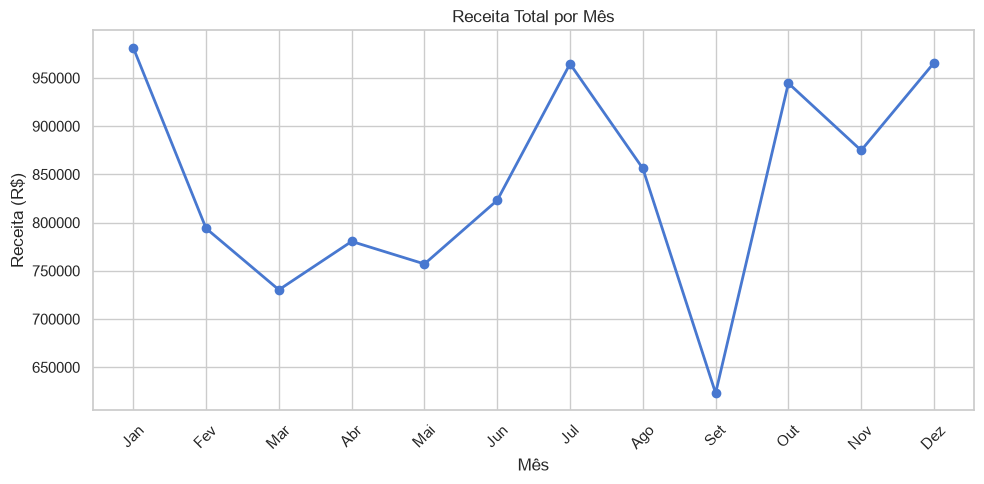

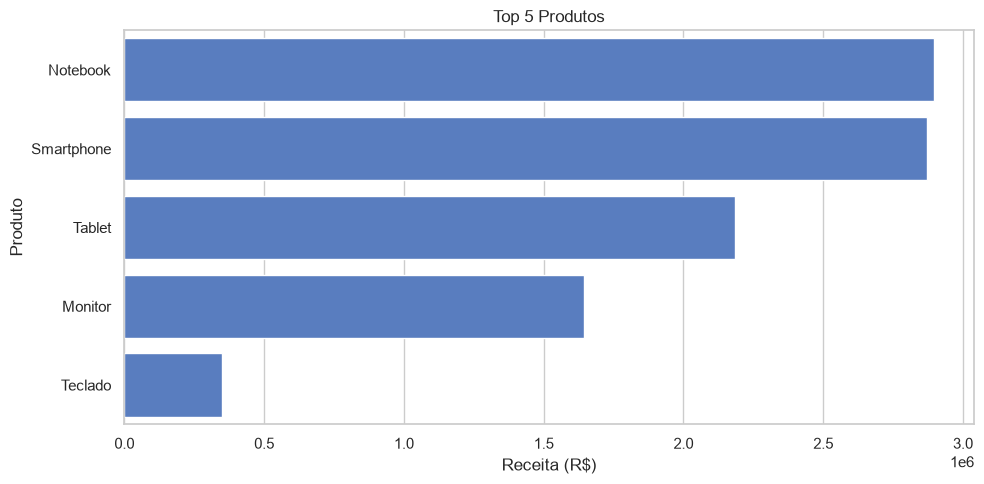

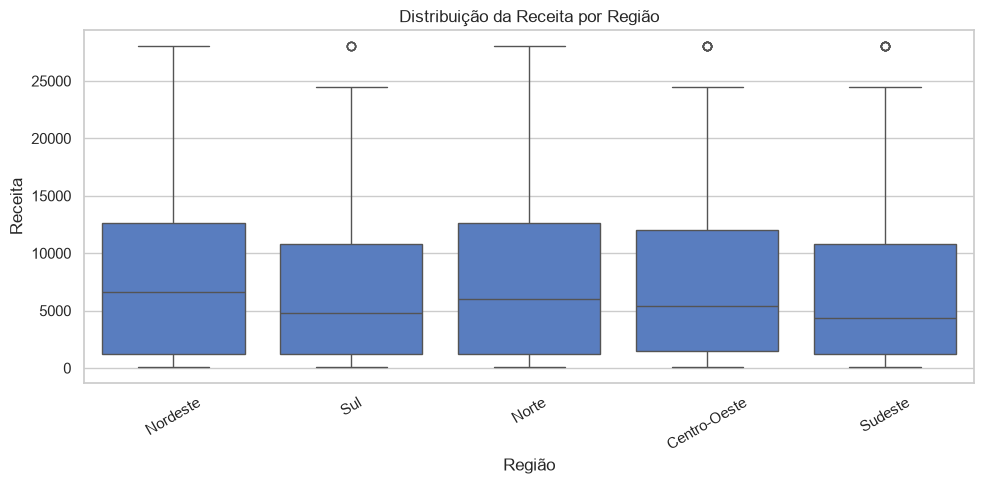


Gráficos salvos em:
../outputs/graficos


In [ ]:
#Gerar visualizações gráficas do dataset final (df_final) e das métricas calculadas (metricas)
gerar_visualizacoes(df_final, metricas)

RF10 – Organizar o Código em Funções Reutilizáveis
Todo o fluxo de análise deve estar encapsulado em funções, e não em código solto espalhado pelas células. Espera-se que o estudante:
Crie funções com parâmetros e retorno para cada etapa (carregar, limpar, transformar, agregar, visualizar);
Documente cada função com uma docstring explicando o que ela faz;
Reutilize ao menos uma função em mais de um contexto (ex.: a mesma limpeza usada para gerar a v1 e a v2);
Use ao menos uma função lambda (por exemplo, na segmentação de clientes).
Opcional (bônus): criar uma função que recebe outra função como parâmetro (callback), demonstrando funções de ordem superior.


In [97]:
#Aplicar uma função a uma coluna do DataFrame
def aplicar_transformacao(df, coluna, funcao):
    """
    Aplica uma função a uma coluna do DataFrame.

    Parâmetros:
        df : DataFrame
        coluna : nome da coluna
        funcao : função ou lambda

    Retorna:
        DataFrame com uma nova coluna transformada.
    """

    df = df.copy()

    df[f"{coluna}_transformado"] = df[coluna].apply(funcao)

    return df

In [98]:
#Aplicar uma função lambda para classificar a receita total em "Alto" ou "Normal"
df_demo = aplicar_transformacao(
    df_final,
    "receita_total",
    lambda x: "Alto" if x > 5000 else "Normal"
)

print(df_demo[
    ["receita_total", "receita_total_transformado"]
].head())

   receita_total receita_total_transformado
0          480.0                     Normal
1        19800.0                       Alto
2         3500.0                     Normal
4        24500.0                       Alto
5         2200.0                     Normal


In [101]:
#Aplicar uma função lambda para transformar a receita total em milhares (dividindo por 1000 e arredondando para 2 casas decimais)
df_demo2 = aplicar_transformacao(
    df_final,
    "receita_total",
    lambda x: round(x / 1000, 2)
)

print(df_demo2[
    ["receita_total", "receita_total_transformado"]
].head())

   receita_total  receita_total_transformado
0          480.0                        0.48
1        19800.0                       19.80
2         3500.0                        3.50
4        24500.0                       24.50
5         2200.0                        2.20


RF11 – Ler e Escrever Arquivos (CSV e JSON)
O projeto deverá demonstrar a leitura e a escrita de arquivos em pelo menos dois formatos.


In [104]:
#Exportar resultados em CSV e JSON
import os
import json

def exportar_resultados(metricas, clientes, estatisticas):
    """
    Exporta os resultados da análise em CSV e JSON.
    """

    os.makedirs("outputs", exist_ok=True)

    # ============================
    # Exportação CSV
    # ============================

    metricas["por_mes"].to_csv(
        "../outputs/metricas_por_mes.csv",
        index=False,
        encoding="utf-8-sig"
    )

    print("Arquivo salvo:")
    print("../outputs/metricas_por_mes.csv")

    clientes.to_csv(
        "../outputs/segmentacao_clientes.csv",
        index=False,
        encoding="utf-8-sig"
    )

    print("Arquivo salvo:")
    print("../outputs/segmentacao_clientes.csv")

    # ============================
    # Exportação JSON
    # ============================

    estatisticas_json = {
        chave: round(float(valor), 2)
        for chave, valor in estatisticas.items()
    }

    caminho = "../outputs/estatisticas_gerais.json"

    with open(caminho, "w", encoding="utf-8") as arquivo:
        json.dump(
            estatisticas_json,
            arquivo,
            indent=4,
            ensure_ascii=False
        )

    print("Arquivo salvo:")
    print(caminho)

    # ============================
    # Leitura do JSON
    # ============================

    with open(caminho, "r", encoding="utf-8") as arquivo:
        dados = json.load(arquivo)

    print("\nJSON lido com sucesso:\n")

    print(json.dumps(
        dados,
        indent=4,
        ensure_ascii=False
    ))

In [106]:
#Salvar os resultados da análise em CSV e JSON
exportar_resultados(
    metricas,
    clientes,
    estatisticas
)

Arquivo salvo:
../outputs/metricas_por_mes.csv
Arquivo salvo:
../outputs/segmentacao_clientes.csv
Arquivo salvo:
../outputs/estatisticas_gerais.json

JSON lido com sucesso:

{
    "media": 7472.58,
    "mediana": 5400.0,
    "desvio_padrao": 7192.43,
    "total": 10095460.0,
    "minimo": 120.0,
    "maximo": 28000.0,
    "percentil_25": 1200.0,
    "percentil_75": 12000.0,
    "acima_da_media": 538.0
}
